# Estimating Expression Functions with `smooth_expression`

`kompot.smooth_expression` fits a **Gaussian process over the cell-state embedding** to
turn noisy per-cell counts into a smooth *expression function* `f(state)` — plus a per-cell
**uncertainty** (the GP posterior standard deviation).

This is the **same machinery `kompot.de` uses internally**: differential expression fits one
of these functions per condition and contrasts them. Using the primitive directly unlocks
three things DE wraps up: choosing the **length scale**, reading the **uncertainty**, and
**training on some cells then predicting on others** (imputation, modality transfer,
counterfactual expression).

We start with the plainest possible call and add one idea at a time.

**Dive deeper:**
[Getting Started / DE](./01_getting_started.ipynb) ·
[Advanced DE + `ls_factor`](./02_differential_expression_detailed.ipynb) ·
[Sample variance](./03_sample_variance.ipynb) ·
[Paper](https://www.biorxiv.org/content/10.1101/2025.06.03.657769)

In [1]:
%matplotlib inline

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
from scipy import sparse

import kompot

# Consistent, clean plotting style across the tutorial set
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["image.cmap"] = "Spectral_r"

## Configuration

Same dataset and cell-state representation as the DE tutorials:

In [2]:
DATA_PATH = "../data/murine_bone_marrow_aging.h5ad"
GROUPING_COLUMN = "Age"                       # condition column in adata.obs
CONDITIONS = ["Young", "Old"]                 # first entry is the reference
CELL_TYPE_COLUMN = "highres_celltype"         # for visualization only
DIMENSIONALITY_REDUCTION = "DM_EigenVectors"  # cell-state representation
LAYER_FOR_EXPRESSION = "logged_counts"        # expression layer

# A few lineage markers to smooth (myeloid, B, erythroid programs).
GENES = ["Elane", "Mpo", "Cd79a", "Car2"]


def dense(x):
    return np.asarray(x.todense()).ravel() if sparse.issparse(x) else np.asarray(x).ravel()

## Load Data

In [3]:
import os
from pathlib import Path

import requests
from tqdm.auto import tqdm

Path(DATA_PATH).parent.mkdir(parents=True, exist_ok=True)

if not os.path.exists(DATA_PATH):
    print("Downloading dataset (~2.4 GB) from Zenodo ...")
    url = "https://zenodo.org/records/15587768/files/murine_bone_marrow_aging.h5ad?download=1"
    response = requests.get(url, stream=True)
    total = int(response.headers.get("content-length", 0))
    with open(DATA_PATH, "wb") as file, tqdm(total=total, unit="B", unit_scale=True) as bar:
        for chunk in response.iter_content(chunk_size=1 << 20):
            file.write(chunk)
            bar.update(len(chunk))

adata = ad.read_h5ad(DATA_PATH)
adata

AnnData object with n_obs × n_vars = 8090 × 16285
    obs: 'Compartment', 'Replicate', 'Age', 'Sample', 'Info', 'batch', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden', 'phenograph', 'highres_celltype', 'midres_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Age_colors', 'Compartment_colors', 'DMEigenValues', 'DM_EigenValues', 'Info_colors', 'README', 'Replicate_colors', 'Sample_colors', 'batch_colors', 'draw_graph', 'highres_celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'midres_celltype_colors', 'neighbors', 'pca', 'phase_colors', 'umap'
    obsm: 'AbCapture', 'DM_EigenVectors', 'HTO', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_

## 1. The vanilla case

Fit an expression function on **all** cells. Give it the cell-state representation, the
expression layer, and the genes you care about — that is the whole call:

In [4]:
kompot.smooth_expression(
    adata,
    obsm_key=DIMENSIONALITY_REDUCTION,
    layer=LAYER_FOR_EXPRESSION,
    genes=GENES,
)

smoothed = "kompot_smooth_all_smoothed"   # layer: the fitted function, per cell
std = "kompot_smooth_all_std"             # layer: its posterior standard deviation

adata

[2026-07-11 22:39:03,876] [INFO    ] Smoothing all 8,090 cells


AnnData object with n_obs × n_vars = 8090 × 16285
    obs: 'Compartment', 'Replicate', 'Age', 'Sample', 'Info', 'batch', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden', 'phenograph', 'highres_celltype', 'midres_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Age_colors', 'Compartment_colors', 'DMEigenValues', 'DM_EigenValues', 'Info_colors', 'README', 'Replicate_colors', 'Sample_colors', 'batch_colors', 'draw_graph', 'highres_celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'midres_celltype_colors', 'neighbors', 'pca', 'phase_colors', 'umap', 'kompot_smooth'
    obsm: 'AbCapture', 'DM_EigenVectors', 'HTO', 'X_draw_graph_fa', 'X_pca', 'X_

Two new layers. The raw counts are noisy and full of dropouts; the fitted function denoises
them into a smooth surface over cell state, and the posterior std says how much to trust it
at each cell. Look at all three for one gene:

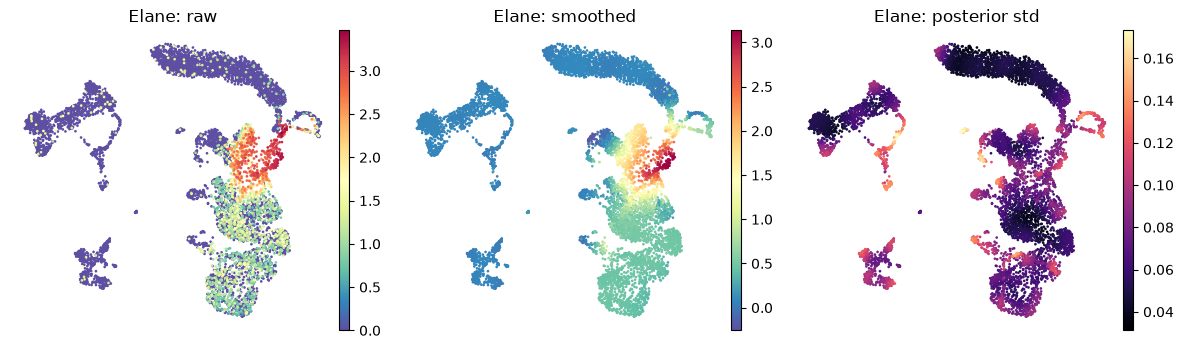

In [5]:
gene = GENES[0]
gi = adata.var_names.get_loc(gene)

adata.obs[f"{gene}: raw"] = dense(adata[:, gene].layers[LAYER_FOR_EXPRESSION])
adata.obs[f"{gene}: smoothed"] = adata.layers[smoothed][:, gi]
adata.obs[f"{gene}: posterior std"] = adata.layers[std][:, gi]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
sc.pl.embedding(adata, "umap", color=f"{gene}: raw", ax=axes[0], show=False,
                frameon=False, cmap="Spectral_r")
sc.pl.embedding(adata, "umap", color=f"{gene}: smoothed", ax=axes[1],
                show=False, frameon=False, cmap="Spectral_r")
sc.pl.embedding(adata, "umap", color=f"{gene}: posterior std", ax=axes[2],
                show=False, frameon=False, cmap="magma")
plt.tight_layout()

That is the primitive: a **denoised expression function** and a **calibrated uncertainty**
on the same cell-state geometry. Uncertainty is highest where cells are sparse — the model
tells you where it is guessing.

Everything below is the same call with one knob turned.

## 2. The length scale

The **length scale** sets how far the GP pools information across neighbouring cells.
`GPSettings(ls_factor=...)` scales the automatically inferred length scale (default `10`).
Fit the same gene at a low, medium, and high `ls_factor` and read the smoothed value (top)
against its posterior std (bottom):

[2026-07-11 22:40:18,175] [INFO    ] Smoothing all 8,090 cells


[2026-07-11 22:41:37,041] [INFO    ] Smoothing all 8,090 cells


[2026-07-11 22:43:03,245] [INFO    ] Smoothing all 8,090 cells


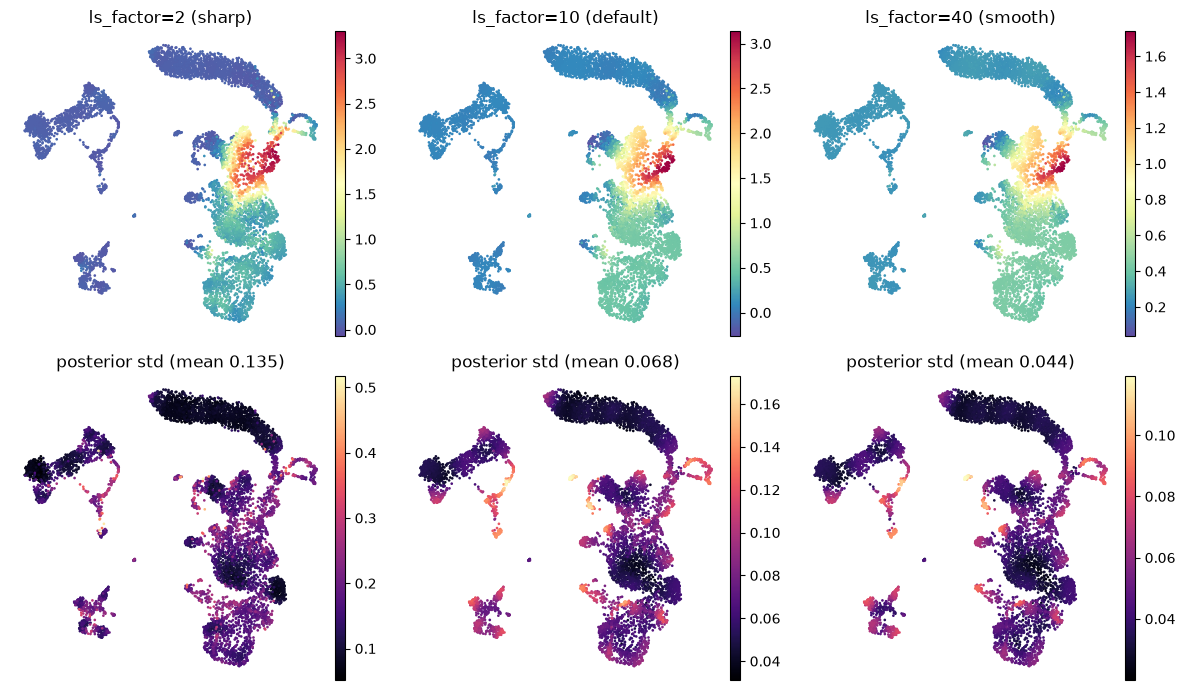

In [6]:
scales = [(2.0, "sharp"), (10.0, "default"), (40.0, "smooth")]
X = adata.obsm[DIMENSIONALITY_REDUCTION]
gj = GENES.index(gene)

fig, axes = plt.subplots(2, len(scales), figsize=(4 * len(scales), 7))
for k, (lsf, tag) in enumerate(scales):
    model = kompot.smooth_expression(
        adata,
        obsm_key=DIMENSIONALITY_REDUCTION, layer=LAYER_FOR_EXPRESSION, genes=GENES,
        gp=kompot.GPSettings(ls_factor=lsf),
        storage=kompot.StorageSettings(result_key=f"ls_{tag}"),
        output=kompot.OutputSettings(return_full_results=True, inplace=False, progress=False),
    )["model"]
    values = model.predict(X, progress=False)[:, gj]
    sd = model.std(X, progress=False)
    sd = sd[:, gj] if sd.ndim == 2 else sd.ravel()

    adata.obs["_value"], adata.obs["_sd"] = values, sd
    sc.pl.embedding(adata, "umap", color="_value", ax=axes[0, k], show=False,
                    frameon=False, cmap="Spectral_r", title=f"ls_factor={lsf:g} ({tag})")
    sc.pl.embedding(adata, "umap", color="_sd", ax=axes[1, k], show=False,
                    frameon=False, cmap="magma",
                    title=f"posterior std (mean {sd.mean():.3f})")
adata.obs.drop(columns=["_value", "_sd"], inplace=True)
plt.tight_layout()

Larger `ls_factor` → a **smoother** surface with **lower** posterior uncertainty, at the
cost of **coarser** resolution (fine structure is averaged away); smaller `ls_factor` does
the reverse. That is the resolution–uncertainty trade-off. The
[Advanced DE tutorial](./02_differential_expression_detailed.ipynb) covers `ls_factor` in the
DE setting; the [paper](https://www.biorxiv.org/content/10.1101/2025.06.03.657769) gives the theory.

## 3. Fit on some cells, predict on others

The model is *fit* on the cells you give it but can be *evaluated* at any coordinates, so it
doubles as a fit/predict surface. The bare-array estimator underneath `smooth_expression` is
[`ExpressionModel`](https://kompot.readthedocs.io/en/latest/api.html):

- `ExpressionModel().fit(X, y)` — learn the function from cell-state coordinates
  `X` `(n_cells, n_dims)` and values `y` `(n_cells, n_features)`.
- `.predict(X)` / `.std(X)` — evaluate the function and its uncertainty at **any** coordinates.

### Imputing a sparsely measured modality

When a measurement exists on only **some** cells (a surface-protein panel, a spatial
readout, a second assay), the same GP transfers it to the rest.

To grade the transfer honestly, take a real gene, hide it on a **random 30% of cells**, fit
on the rest, and impute the hidden ones. Random cells are the right hold-out here: they are
**interspersed** among measured cells, so every imputed cell has observed neighbours. That
is the realistic modality-transfer regime. (Blanking one *contiguous* region instead would
ask the model to extrapolate into states it has no representatives for — a different and
much harder problem, and one the posterior std would correctly flag as unreliable.)

Because we hid real measurements, the ground truth is available to score against — a
built-in cross-validation.

In [7]:
truth = dense(adata[:, gene].layers[LAYER_FOR_EXPRESSION])   # full, pre-masking
X = adata.obsm[DIMENSIONALITY_REDUCTION]

rng = np.random.default_rng(0)                               # seeded: reproducible
missing = rng.random(adata.n_obs) < 0.30                     # 30% of cells, at random
observed = ~missing

measured = truth.copy()
measured[missing] = np.nan                                   # the modality, on ~70% of cells

# Bare-array fit/predict — the estimator underneath smooth_expression.
model = kompot.ExpressionModel()
model.fit(X[observed], measured[observed][:, None])          # train on measured cells only

completed = measured.copy()                                  # measured cells keep their value
completed[missing] = model.predict(X[missing], progress=False)[:, 0]   # the rest are imputed

adata.obs[f"{gene}: measured (30% blanked)"] = measured
adata.obs[f"{gene}: completed (imputed)"] = completed
print(f"imputed {int(missing.sum())} cells from {int(observed.sum())} measured cells")

imputed 2445 cells from 5645 measured cells


The masked cells are scattered everywhere (grey), not carved out of one region; the
completed layer fills them in from the shared cell-state geometry:

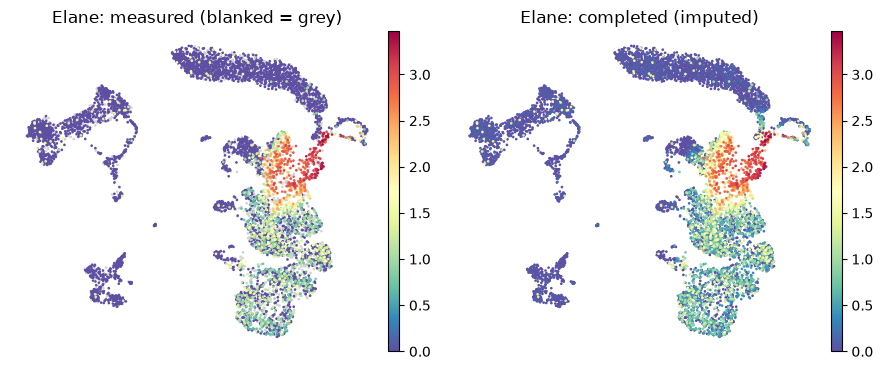

In [8]:
vmin, vmax = np.nanmin(truth), np.nanmax(truth)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
sc.pl.embedding(adata, "umap", color=f"{gene}: measured (30% blanked)", ax=axes[0],
                show=False, frameon=False, cmap="Spectral_r", vmin=vmin, vmax=vmax,
                na_color="lightgrey", title=f"{gene}: measured (blanked = grey)")
sc.pl.embedding(adata, "umap", color=f"{gene}: completed (imputed)", ax=axes[1],
                show=False, frameon=False, cmap="Spectral_r", vmin=vmin, vmax=vmax,
                title=f"{gene}: completed (imputed)")
plt.tight_layout()

Now grade it against the truth we hid. Two populations tell two different stories — the
**imputed** cells (never seen during the fit) and the **smoothed** input cells (denoised
training values) — so we report a separate correlation for each:

imputed  r = 0.820
smoothed r = 0.821


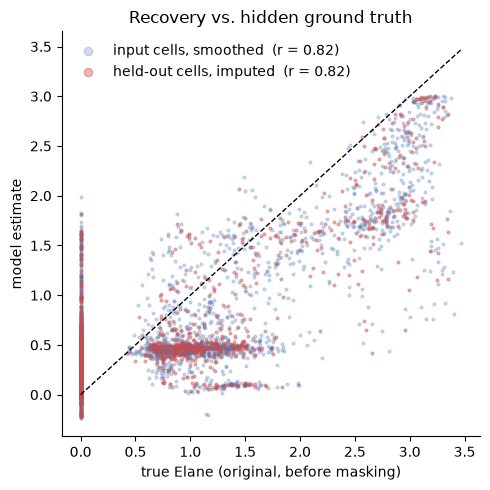

In [9]:
pred_imputed = model.predict(X[missing], progress=False)[:, 0]    # held-out cells
pred_smoothed = model.predict(X[observed], progress=False)[:, 0]  # training cells

r_imputed = np.corrcoef(pred_imputed, truth[missing])[0, 1]
r_smoothed = np.corrcoef(pred_smoothed, truth[observed])[0, 1]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(truth[observed], pred_smoothed, s=4, alpha=0.25, color="#4C72B0",
           label=f"input cells, smoothed  (r = {r_smoothed:.2f})")
ax.scatter(truth[missing], pred_imputed, s=4, alpha=0.40, color="#C44E52",
           label=f"held-out cells, imputed  (r = {r_imputed:.2f})")
lims = [float(np.nanmin(truth)), float(np.nanmax(truth))]
ax.plot(lims, lims, "k--", lw=1)
ax.set(xlabel=f"true {gene} (original, before masking)", ylabel="model estimate",
       title="Recovery vs. hidden ground truth")
ax.legend(loc="upper left", frameon=False, markerscale=3)
plt.tight_layout()

print(f"imputed  r = {r_imputed:.3f}")
print(f"smoothed r = {r_smoothed:.3f}")

The two correlations land in the **same place**: cells the model never saw are recovered as
accurately as the training cells are denoised. That is the signature of a well-posed
transfer — every held-out cell sits among measured neighbours, so the GP interpolates rather
than extrapolates. If you instead hide a whole region of the manifold, the imputed
correlation drops sharply and `model.std(X)` lights up over exactly those cells; the
uncertainty is there to tell you which regime you are in.

The fitted model is reusable without refitting: `ModelSettings(model1=model)` injects it
into `smooth_expression` or `kompot.de` to write imputed values into another AnnData.

## 4. Counterfactual expression

Fit the function on **one condition**, then evaluate it at *other* cells' states: the result
is *what expression would be if those cells followed that condition's program*. Contrast the
Young function against the Old function — their difference is exactly the log fold change
`kompot.de` reports.

[2026-07-11 22:44:58,228] [INFO    ] Smoothing condition 'Young': 2,917 cells


[2026-07-11 22:45:18,283] [INFO    ] Smoothing condition 'Old': 3,116 cells


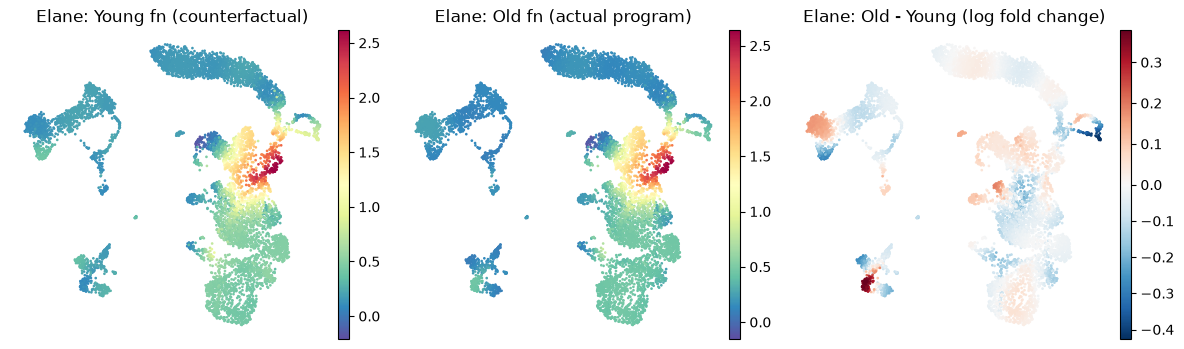

In [10]:
def condition_model(condition):
    return kompot.smooth_expression(
        adata, groupby=GROUPING_COLUMN, condition=condition,
        obsm_key=DIMENSIONALITY_REDUCTION, layer=LAYER_FOR_EXPRESSION, genes=GENES,
        output=kompot.OutputSettings(return_full_results=True, inplace=False, progress=False),
    )["model"]


young_fn = condition_model(CONDITIONS[0])
old_fn = condition_model(CONDITIONS[1])

young_pred = young_fn.predict(X, progress=False)[:, gj]   # counterfactual reference
old_pred = old_fn.predict(X, progress=False)[:, gj]

adata.obs[f"{gene}: Young fn (counterfactual)"] = young_pred
adata.obs[f"{gene}: Old fn (actual program)"] = old_pred
adata.obs[f"{gene}: Old - Young (log fold change)"] = old_pred - young_pred

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
sc.pl.embedding(adata, "umap", color=f"{gene}: Young fn (counterfactual)", ax=axes[0],
                show=False, frameon=False, cmap="Spectral_r")
sc.pl.embedding(adata, "umap", color=f"{gene}: Old fn (actual program)", ax=axes[1],
                show=False, frameon=False, cmap="Spectral_r")
sc.pl.embedding(adata, "umap", color=f"{gene}: Old - Young (log fold change)", ax=axes[2],
                show=False, frameon=False, cmap="RdBu_r", vcenter=0)
plt.tight_layout()

That third panel *is* differential expression, computed by hand. `kompot.de` does this for
every gene at once and adds the covariance-aware significance on top — see
[Getting Started](./01_getting_started.ipynb).

## Where to go deeper

- **[Getting Started / DE](./01_getting_started.ipynb)** — the front door; `smooth_expression` is the primitive underneath.
- **[Advanced DE + `ls_factor`](./02_differential_expression_detailed.ipynb)** — the length-scale trade-off in the DE setting.
- **[DE with sample variance](./03_sample_variance.ipynb)** — per-gene aleatoric and replicate uncertainty (this tutorial shows the GP/epistemic term).
- **[Differential abundance](./04_differential_abundance.ipynb)** — the same GP geometry applied to cell-state frequency.
- **[Paper](https://www.biorxiv.org/content/10.1101/2025.06.03.657769)** ·
  **[Documentation](https://kompot.readthedocs.io)**